In [1]:
import pandas as pd
team = pd.read_csv('Teams.csv')

In [2]:
year_total = team.groupby('yearID')[['SB','CS','G', 'R']].sum()

year_total = year_total.sort_values('yearID', ascending=False)

year_total['SB_Percentage'] = year_total['SB'] / ((year_total['SB'] + year_total['CS']))*100

year_total['SB_Per_Game'] = year_total['SB'] / year_total['G']

year_total['R_Per_Game'] = year_total['R'] / year_total['G']

year_total['Rule_Changes'] = year_total.index.map(lambda x: 'Pre_Rule_Changes' if x <= 2022 else 'Post_Rule_Changes')


modern_data = year_total.loc[year_total.index >= 2000]
modern_data = modern_data[modern_data.index != 2020]

avg_sb_percentage = modern_data.groupby('Rule_Changes')['SB_Percentage'].mean()
avg_sb_per_game = modern_data.groupby('Rule_Changes')['SB_Per_Game'].mean()
avg_r_per_game = modern_data.groupby('Rule_Changes')['R_Per_Game'].mean()
avg_sb_per_year = modern_data.groupby('Rule_Changes')['SB'].mean()

comparison = modern_data.groupby('Rule_Changes')[
    ['SB_Per_Game', 'SB_Percentage', 'R_Per_Game']
].mean()

comparison.loc['Percent_Change'] = (
    (comparison.loc['Post_Rule_Changes'] - comparison.loc['Pre_Rule_Changes'])
    / comparison.loc['Pre_Rule_Changes']
) * 100

print(comparison)

                   SB_Per_Game  SB_Percentage  R_Per_Game
Rule_Changes                                             
Post_Rule_Changes     0.724382      78.952245    4.485445
Pre_Rule_Changes      0.560405      71.941747    4.558081
Percent_Change       29.260375       9.744687   -1.593573


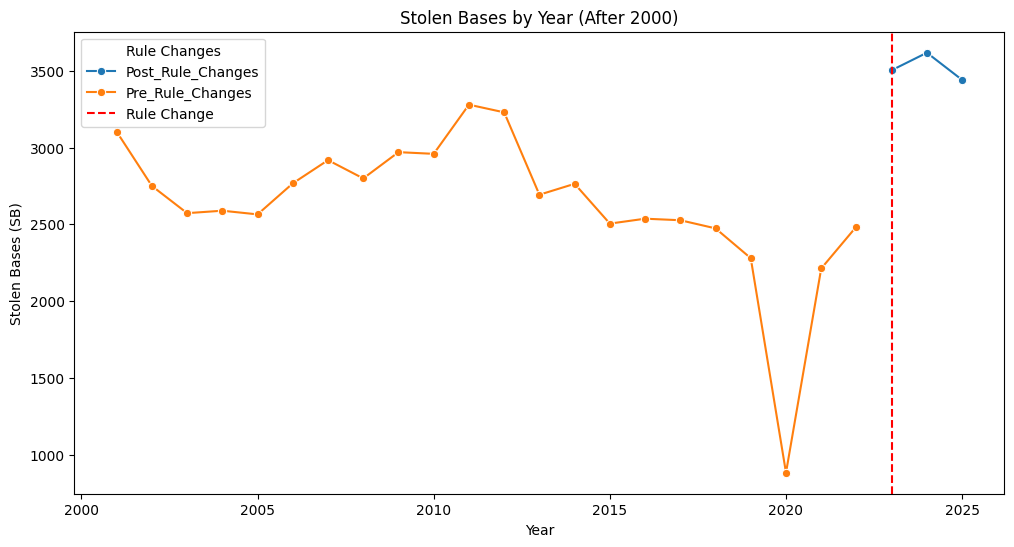

In [3]:
import seaborn as sns

import matplotlib.pyplot as plt

plot_data = year_total.loc[year_total.index > 2000].reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=plot_data, x='yearID', y='SB', hue='Rule_Changes', marker='o')
plt.title('Stolen Bases by Year (After 2000)')
plt.xlabel('Year')
plt.ylabel('Stolen Bases (SB)')
plt.axvline(x=2023, color='red', linestyle='--', label='Rule Change')
plt.legend(title='Rule Changes')
plt.show()

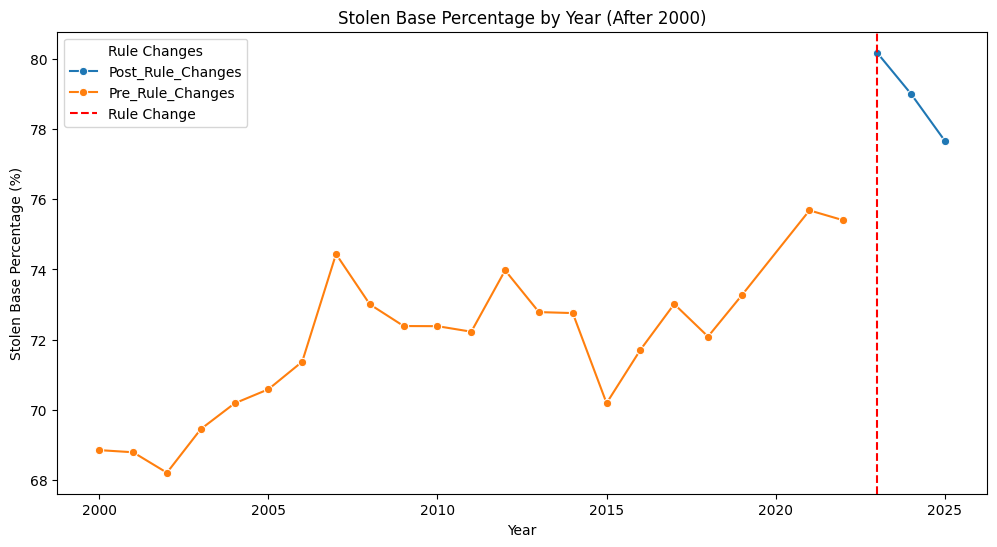

In [4]:

plt.figure(figsize=(12, 6))
sns.lineplot(data=modern_data, x='yearID', y='SB_Percentage', hue='Rule_Changes', marker='o')
plt.axvline(x=2023, color='red', linestyle='--', label='Rule Change')
plt.title('Stolen Base Percentage by Year (After 2000)')
plt.xlabel('Year')
plt.ylabel('Stolen Base Percentage (%)')
plt.legend(title='Rule Changes')
plt.show()

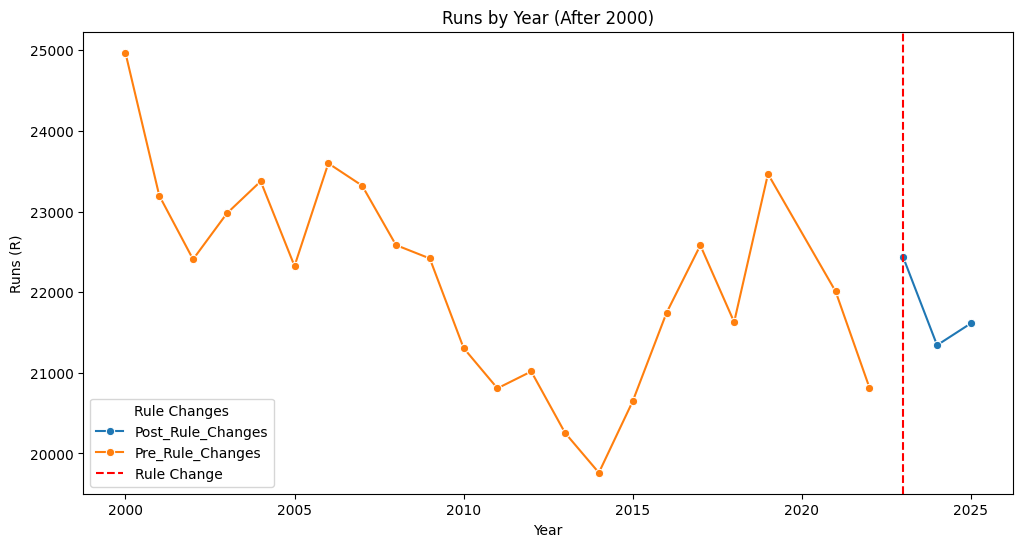

In [5]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=modern_data, x='yearID', y='R', hue='Rule_Changes', marker='o')
plt.axvline(x=2023, color='red', linestyle='--', label='Rule Change')
plt.title('Runs by Year (After 2000)')
plt.xlabel('Year')
plt.ylabel('Runs (R)')
plt.legend(title='Rule Changes')
plt.show()

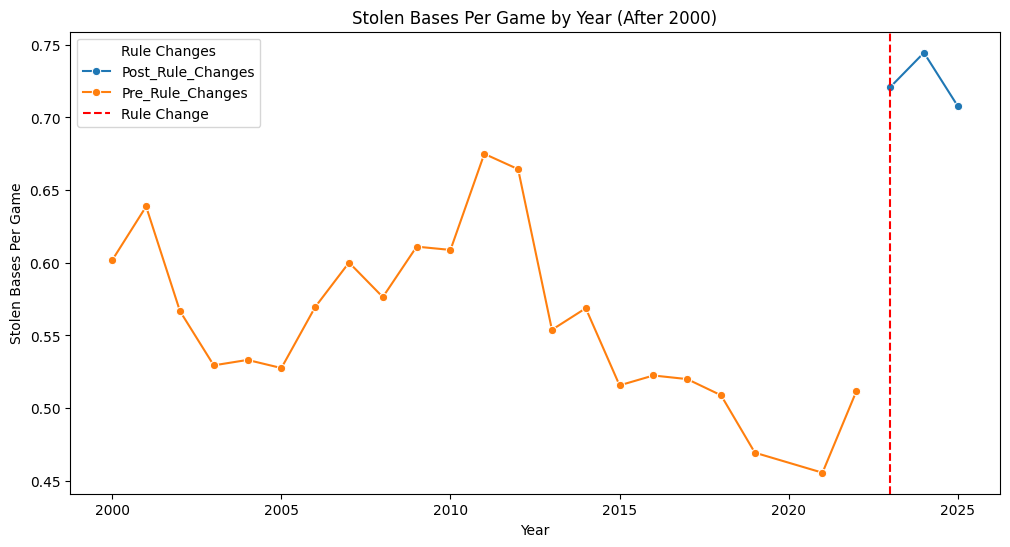

In [6]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=modern_data, x='yearID', y='SB_Per_Game', hue='Rule_Changes', marker='o')
plt.axvline(x=2023, color='red', linestyle='--', label='Rule Change')
plt.title('Stolen Bases Per Game by Year (After 2000)')
plt.xlabel('Year')
plt.ylabel('Stolen Bases Per Game')
plt.legend(title='Rule Changes')
plt.show()

In [7]:
correlation = modern_data['SB_Per_Game'].corr(modern_data['R_Per_Game'])

print(correlation)

-0.09422392062962155


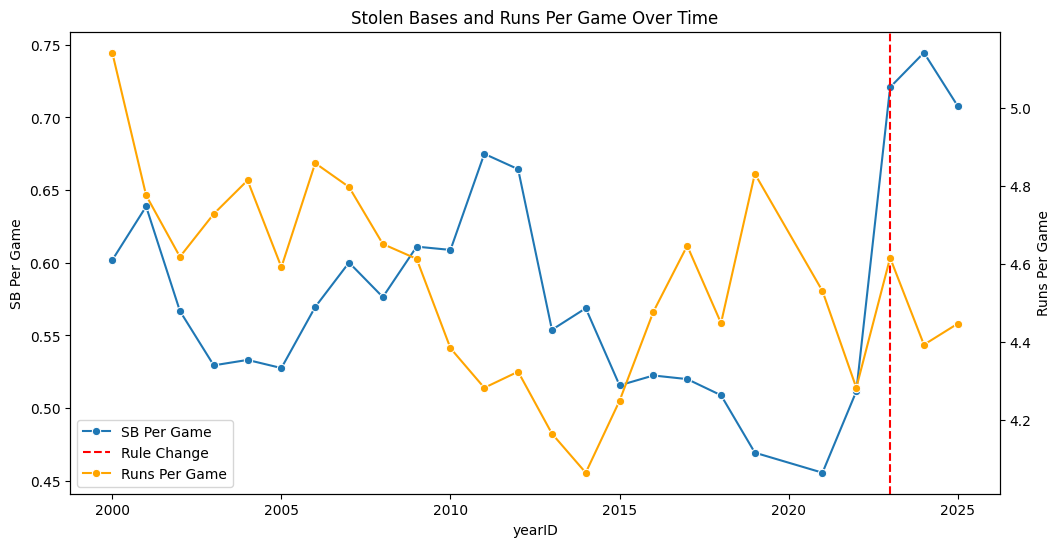

In [8]:
fig, ax1 = plt.subplots(figsize=(12,6))

sns.lineplot(
    data=modern_data,
    x='yearID',
    y='SB_Per_Game',
    ax=ax1,
    marker='o',
    label='SB Per Game'
)

ax2 = ax1.twinx()

sns.lineplot(
    data=modern_data,
    x='yearID',
    y='R_Per_Game',
    ax=ax2,
    color = 'orange',
    marker='o',
    label='Runs Per Game',
    legend = False
)

ax1.axvline(2023, color='red', linestyle='--', label='Rule Change')

ax1.set_ylabel('SB Per Game')
ax2.set_ylabel('Runs Per Game')

plt.title('Stolen Bases and Runs Per Game Over Time')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc='lower left')

plt.show()

In [9]:
from scipy.stats import ttest_ind

pre_rule = modern_data[
    modern_data['Rule_Changes'] == 'Pre_Rule_Changes'
]['SB_Per_Game']

post_rule = modern_data[
    modern_data['Rule_Changes'] == 'Post_Rule_Changes'
]['SB_Per_Game']

t_stat, p_value = ttest_ind(
    post_rule,
    pre_rule,
    equal_var=False
)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: 9.992255345927997
P-Value: 2.844090386688386e-06


A Welch’s two-sample t-test was performed to compare stolen bases per game before and after the 2023 MLB rule changes. The results showed a statistically significant increase in stolen bases per game following the rule changes (t = 9.99, p < 0.001).

In [10]:
pre_rule = modern_data[
    modern_data['Rule_Changes'] == 'Pre_Rule_Changes'
]['SB_Percentage']

post_rule = modern_data[
    modern_data['Rule_Changes'] == 'Post_Rule_Changes'
]['SB_Percentage']

t_stat, p_value = ttest_ind(
    post_rule,
    pre_rule,
    equal_var=False
)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: 8.257438348338642
P-Value: 0.0015997749750815157


MLB players not only attempted more stolen bases, but they were also more successful after the rule changes.

In [11]:
pre_rule = modern_data[
    modern_data['Rule_Changes'] == 'Pre_Rule_Changes'
]['R_Per_Game']

post_rule = modern_data[
    modern_data['Rule_Changes'] == 'Post_Rule_Changes'
]['R_Per_Game']

t_stat, p_value = ttest_ind(
    post_rule,
    pre_rule,
    equal_var=False
)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: -0.8296773046816802
P-Value: 0.4407331125042471


Although stolen bases increased significantly, runs per game did not show a statistically significant increase.

The 2023 MLB rule changes successfully increased stolen base activity and efficiency, but the increase in baserunning has not yet produced a statistically significant rise in run scoring.